In [1]:
import torch
import torchvision
from tqdm import tqdm_notebook as tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import plotly.graph_objects as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from torchsummary import summary
from torch.utils.data import random_split
import torchvision.transforms as transforms
import numpy as np
import gc

In [2]:
device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device=torch.device('cpu')
device

device(type='cuda', index=0)

## **Tensorboard**

TensorBoard is a visualization toolkit for machine learning experimentation. TensorBoard allows tracking and visualizing metrics such as loss and accuracy, visualizing the model graph, viewing histograms, displaying images and much more. 

### **Installation**

In [3]:
!pip install tensorboard

# **CalTech-101 Dataset Solving**

### **Prepare Data**

In [4]:
transform = torchvision.transforms.Compose([
    # torchvision.transforms.ToPILImage(),
    transforms.Lambda(lambda img: img.convert('RGB')),
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean = [0.5442, 0.5272, 0.5014], std = [0.3127, 0.3067, 0.3192])
])

pip install gdown (load from Google Disk)

In [ ]:
data_path = 'caltech-101/'
dataset = torchvision.datasets.Caltech101(data_path, train=False, download=True, transform=transform)



In [6]:
data_len = len(dataset)
train_len = int(0.7 * data_len)
val_len = int(0.15 * data_len)
test_len = data_len - train_len - val_len

In [7]:
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_len, val_len, test_len])

In [8]:
batch_size = 64
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_data_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_data_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

#### **Is Data Normalized**

In [9]:
means = []
stdevs = []
for X, _ in train_data_loader:
    # Dimensions 0,2,3 are respectively the batch, height and width dimensions
    means.append(X.mean(dim=(0,2,3)))
    stdevs.append(X.std(dim=(0,2,3)))

mean = torch.stack(means, dim=0).mean(dim=0)
stdev = torch.stack(stdevs, dim=0).mean(dim=0)


In [10]:
mean, stdev

(tensor([ 7.6054e-03,  4.0743e-03, -4.5455e-05]),
 tensor([1.0002, 1.0001, 1.0003]))

### **Preparing...**

In [11]:
mean = torch.tensor([0.5442, 0.5272, 0.5014]).to(device)
std = torch.tensor([0.3127, 0.3067, 0.3192]).to(device)

In [12]:
classes = np.arange(101).tolist()
images_num = 16

In [13]:
for images, labels in test_data_loader:
    images_for_logging = images[:images_num]
    labels_for_logging = labels[:images_num]

### **Check Data**

In [14]:
def plot_images(images, rows, cols, figsize=(10, 10)):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()  # Flatten the 2D grid of axes to 1D
    for img, ax in zip(images, axes):
        img = np.transpose(img, (1, 2, 0))
        ax.imshow(img)
        ax.axis('off')  # Turn off axes for each image
    plt.tight_layout()
    plt.show()


In [15]:
images, labels = next(iter(train_data_loader))
images
print(dataset.categories)

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7403262..1.5620301].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3988034..1.5620301].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7403262..1.5497445].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0881946..1.47764].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7403262..1.5620301].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7403262..1.5497445].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7189436.

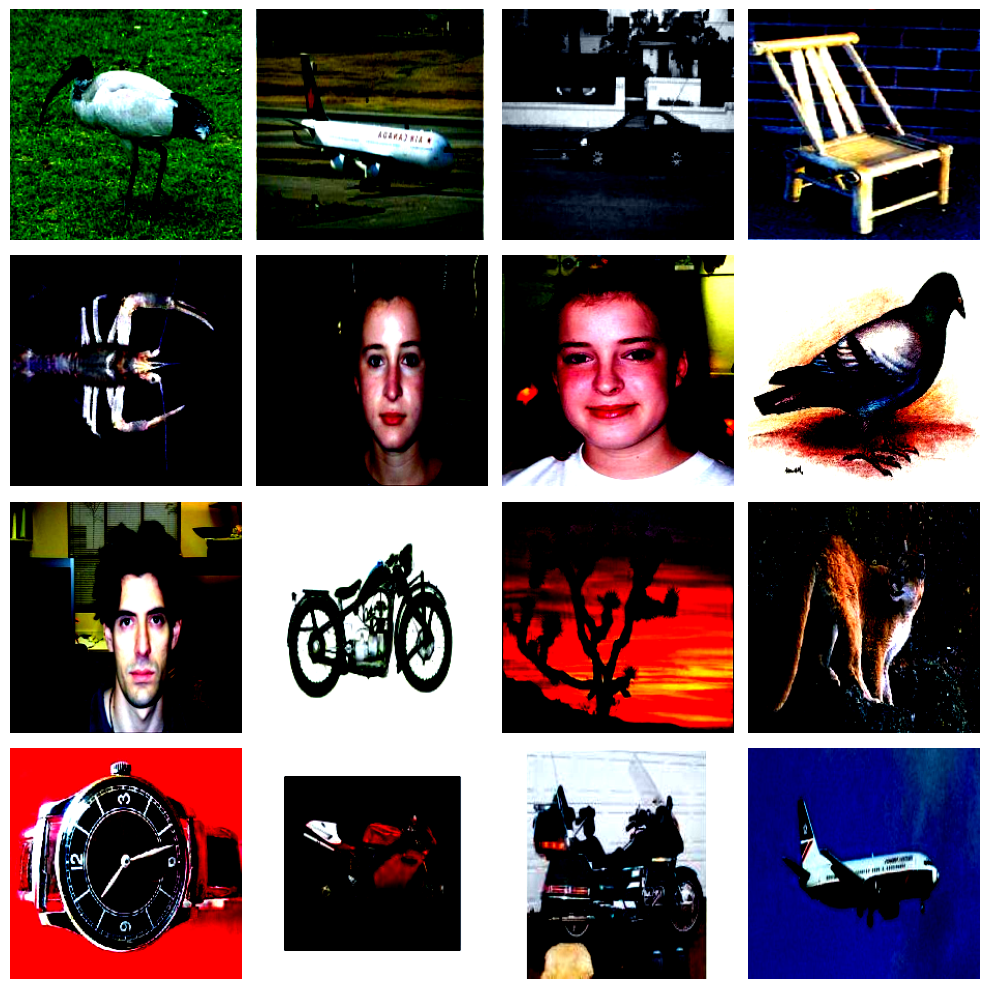

In [16]:
plot_images(images, rows=4, cols=4)

### **Prepare ResNet model**

https://www.digitalocean.com/community/tutorials/writing-resnet-from-scratch-in-pytorch

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Sequential(
                        nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1),
                        nn.BatchNorm2d(out_channels),
                        nn.ReLU())
        self.conv2 = nn.Sequential(
                        nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
                        nn.BatchNorm2d(out_channels))
        self.downsample = downsample
        self.relu = nn.ReLU()
        self.out_channels = out_channels

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

In [18]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes = 101):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Sequential(
                        nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                        nn.BatchNorm2d(64),
                        nn.ReLU())
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
        self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        # self.avgpool = nn.AvgPool2d(2, stride=1)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:

            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm2d(planes),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

### **Prepare MobileNetV1 model**

https://github.com/jmjeon2/MobileNet-Pytorch/blob/master/MobileNetV1.py

In [19]:
class MobileNetV1(nn.Module):
    def __init__(self, ch_in, num_classes):
        super(MobileNetV1, self).__init__()

        def conv_bn(inp, oup, stride):
            return nn.Sequential(
                nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
                nn.BatchNorm2d(oup),
                nn.ReLU(inplace=True)
                )

        def conv_dw(inp, oup, stride):
            return nn.Sequential(
                # dw
                nn.Conv2d(inp, inp, 3, stride, 1, groups=inp, bias=False),
                nn.BatchNorm2d(inp),
                nn.ReLU(inplace=True),

                # pw
                nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
                nn.ReLU(inplace=True),
                )

        self.model = nn.Sequential(
            conv_bn(ch_in, 32, 2),
            conv_dw(32, 64, 1),
            conv_dw(64, 128, 2),
            conv_dw(128, 128, 1),
            conv_dw(128, 256, 2),
            conv_dw(256, 256, 1),
            conv_dw(256, 512, 2),
            conv_dw(512, 512, 1),
            conv_dw(512, 512, 1),
            conv_dw(512, 512, 1),
            conv_dw(512, 512, 1),
            conv_dw(512, 512, 1),
            conv_dw(512, 1024, 2),
            conv_dw(1024, 1024, 1),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.model(x)
        x = x.view(-1, 1024)
        x = self.fc(x)
        return x

### **HyperParams**

In [20]:
num_classes = 101
num_epochs = 10
batch_size = 64
learning_rate = 0.01


### **Train Loop**

In [21]:
def train(num_epochs, model, criterion, optimizer, visualization=False, writer=None):
    total_train_steps = len(train_dataset) / batch_size
    total_val_steps = len(val_dataset) / batch_size
    train_loss = []
    val_loss = []
    error_rate = []

    for epoch in range(num_epochs):
        model.train()
        train_loss_per_epoch = torch.tensor(0.).to(device)
        for i, (images, labels) in enumerate(train_data_loader):  
            #Move tensors to the configured device
            images = images.to(device)
            labels = labels.to(device)

            #Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            train_loss_per_epoch += loss

            #Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        train_loss_per_epoch /= total_train_steps
        train_loss.append(train_loss_per_epoch)
        print ('Epoch [{}/{}], Loss: {:.4f}' 
                    .format(epoch+1, num_epochs, train_loss_per_epoch.item()))

        #Validation
        model.eval()
        val_loss_per_epoch = torch.tensor(0.).to(device)
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in val_data_loader:
                #Move tensors to the configured device
                images = images.to(device)
                labels = labels.to(device)

                #Forward pass
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_per_epoch += loss

                #Parsing outputs
                values, indices = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (indices == labels).sum().item()
            
            val_loss_per_epoch /= total_val_steps
            val_loss.append(val_loss_per_epoch)

            accuracy = 100 * correct / total
            error_rate_per_epoch = torch.as_tensor(100 - accuracy, device=device)
            error_rate.append(error_rate_per_epoch)
            print(f'Accuracy of the network on the {total_val_steps} validation images: {accuracy} %')

        if visualization:
            writer.add_figure('predictions vs. actuals per epoch',
                            plot_classes_preds(model, images_for_logging, labels_for_logging),
                            global_step=epoch)
    return train_loss, val_loss, error_rate

### **Test Loop**

In [22]:
def test(model_name, model):
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_data_loader:
            #Move tensors to the configured device
            images = images.to(device)
            labels = labels.to(device)

            #Forward pass
            outputs = model(images)

            #Parsing outputs
            values, indices = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (indices == labels).sum().item()
        
        print(f'Accuracy of the {model_name}: {100 * correct / total} %')

### **TensorBoard setup**

In [23]:
import torch
from torch.utils.tensorboard import SummaryWriter

In [24]:
output_path = 'runs/ResNet34_exp'
writer = SummaryWriter(output_path)

### **Logging Nums**

In [25]:
train_loss = {}
val_loss = {}
error_rate = {}

In [26]:
def write_scalars(model_name, writer, num_epochs):
    for epoch in range(num_epochs):
        writer.add_scalar('Training Loss', train_loss[model_name][epoch], epoch)
        writer.add_scalar('Validating Loss', val_loss[model_name][epoch], epoch)
        writer.add_scalar('Error rate', error_rate[model_name][epoch], epoch)

### **Logging Images with results**

In [27]:
def images_to_probs(model, images):
    output = model(images)
    # convert output probabilities to predicted class
    _, preds_tensor = torch.max(output, 1)
    preds = torch.squeeze(preds_tensor)
    return preds, [F.softmax(el, dim=0)[i].item() for i, el in zip(preds, output)]

In [28]:
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img * std[:, None, None] + mean[:, None, None]     # unnormalize
    np_img = img.cpu().numpy()
    if one_channel:
        plt.imshow(np_img, cmap="Greys")
    else:
        np_img = np.transpose(np_img, (1, 2, 0))
        np_img = np_img.clip(0, 1)
        plt.imshow((np_img * 255).astype(np.uint8))

In [29]:
def plot_classes_preds(model, images, labels):
    images = images.to(device)
    labels = labels.to(device)
    
    preds, probs = images_to_probs(model, images)
    # plot the images in the batch, along with predicted and true labels
    fig = plt.figure(figsize=(90, 100))
    for idx in np.arange(images_num):
        ax = fig.add_subplot(4, images_num // 4, idx+1, xticks=[], yticks=[])
        matplotlib_imshow(images[idx], one_channel=False)
        ax.set_title("{0}, {1:.1f}%\n(label: {2})".format(
            classes[preds[idx]],
            probs[idx] * 100.0,
            classes[labels[idx]]),
                    color=("green" if preds[idx]==labels[idx].item() else "red"),
                    fontsize=84)
    return fig

### **ResNet34**

In [30]:
model_name = 'ResNet34'
model = ResNet(ResidualBlock, [3, 4, 6, 3], num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.001, momentum = 0.9)

In [31]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer, visualization=True, writer=writer)

Epoch [1/10], Loss: 3.6427
Accuracy of the network on the 20.328125 validation images: 29.746348962336665 %
Epoch [2/10], Loss: 2.7465
Accuracy of the network on the 20.328125 validation images: 36.202920830130665 %
Epoch [3/10], Loss: 2.2712
Accuracy of the network on the 20.328125 validation images: 37.2021521906226 %
Epoch [4/10], Loss: 1.9181
Accuracy of the network on the 20.328125 validation images: 47.65564950038432 %
Epoch [5/10], Loss: 1.5549
Accuracy of the network on the 20.328125 validation images: 44.273635664873176 %
Epoch [6/10], Loss: 1.3093
Accuracy of the network on the 20.328125 validation images: 50.03843197540353 %
Epoch [7/10], Loss: 1.0241
Accuracy of the network on the 20.328125 validation images: 56.57186779400461 %
Epoch [8/10], Loss: 0.7858
Accuracy of the network on the 20.328125 validation images: 57.64796310530361 %
Epoch [9/10], Loss: 0.5351
Accuracy of the network on the 20.328125 validation images: 60.41506533435819 %
Epoch [10/10], Loss: 0.3408
Accurac

In [32]:
test(model_name, model)

Accuracy of the ResNet34: 63.31542594013814 %


#### **Addings to TensorBoard**

In [33]:
write_scalars(model_name, writer, num_epochs)

ADD TRAIN RESULTS TO THESE IMAGES

In [34]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
grid = torchvision.utils.make_grid(images)
writer.add_image('images', grid, 0)
writer.add_graph(model, images)

Call this method to make sure that all pending events have been written to disk

In [35]:
writer.flush()

In [36]:
writer.close()

#### **Free space**

In [37]:
torch.cuda.empty_cache()

### **ResNet18**

In [38]:
model_name = 'ResNet18'
model = ResNet(ResidualBlock, [2, 2, 2, 2], num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.001, momentum = 0.9)

In [39]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

In [40]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer)

Epoch [1/10], Loss: 3.5282
Accuracy of the network on the 20.328125 validation images: 23.82782475019216 %
Epoch [2/10], Loss: 2.7383
Accuracy of the network on the 20.328125 validation images: 35.28055342044581 %
Epoch [3/10], Loss: 2.3292
Accuracy of the network on the 20.328125 validation images: 41.81398923904689 %
Epoch [4/10], Loss: 1.9320
Accuracy of the network on the 20.328125 validation images: 47.65564950038432 %
Epoch [5/10], Loss: 1.6429
Accuracy of the network on the 20.328125 validation images: 50.57647963105303 %
Epoch [6/10], Loss: 1.3530
Accuracy of the network on the 20.328125 validation images: 52.72867025365104 %
Epoch [7/10], Loss: 1.1154
Accuracy of the network on the 20.328125 validation images: 57.9554189085319 %
Epoch [8/10], Loss: 0.8884
Accuracy of the network on the 20.328125 validation images: 57.033051498847044 %
Epoch [9/10], Loss: 0.6905
Accuracy of the network on the 20.328125 validation images: 53.036126056879326 %
Epoch [10/10], Loss: 0.5200
Accuracy

In [41]:
test(model_name, model)

Accuracy of the ResNet18: 65.77129700690713 %


In [42]:
write_scalars(model_name, writer, num_epochs)

In [43]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [44]:
writer.flush()
writer.close()

In [45]:
torch.cuda.empty_cache()


### **MobileNetV1**

In [46]:
model_name = 'MobileNetV1'
model = MobileNetV1(ch_in=3, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [47]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

In [48]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer)

Epoch [1/10], Loss: 3.5143
Accuracy of the network on the 20.328125 validation images: 31.898539584934667 %
Epoch [2/10], Loss: 2.6789
Accuracy of the network on the 20.328125 validation images: 41.58339738662567 %
Epoch [3/10], Loss: 2.1718
Accuracy of the network on the 20.328125 validation images: 44.58109146810146 %
Epoch [4/10], Loss: 1.7371
Accuracy of the network on the 20.328125 validation images: 51.11452728670254 %
Epoch [5/10], Loss: 1.4126
Accuracy of the network on the 20.328125 validation images: 52.03689469638739 %
Epoch [6/10], Loss: 1.1424
Accuracy of the network on the 20.328125 validation images: 53.574173712528825 %
Epoch [7/10], Loss: 0.8414
Accuracy of the network on the 20.328125 validation images: 58.03228285933897 %
Epoch [8/10], Loss: 0.6282
Accuracy of the network on the 20.328125 validation images: 60.876249039200616 %
Epoch [9/10], Loss: 0.4578
Accuracy of the network on the 20.328125 validation images: 59.87701767870868 %
Epoch [10/10], Loss: 0.3140
Accura

In [49]:
test(model_name, model)

Accuracy of the MobileNetV1: 64.62010744435918 %


In [50]:
write_scalars(model_name, writer, num_epochs)

In [51]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [52]:
writer.flush()
writer.close()

In [53]:
torch.cuda.empty_cache()


## **Fine Tuning**

https://github.com/pytorch/vision/tree/main/references/classification

https://www.kaggle.com/code/francescolorenzo/96-fine-tuning-resnet34-with-pytorch

In [54]:
from torchvision.models import resnet18, resnet34, mobilenet_v2
from torchvision.models import ResNet18_Weights, ResNet34_Weights, MobileNet_V2_Weights

### **ResNet18**

In [55]:
model_name = 'finetuned_ResNet18'
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [56]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.001, momentum = 0.9)

In [58]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer)

Epoch [1/10], Loss: 1.4816
Accuracy of the network on the 20.328125 validation images: 89.62336664104535 %
Epoch [2/10], Loss: 0.1801
Accuracy of the network on the 20.328125 validation images: 94.77325134511914 %
Epoch [3/10], Loss: 0.0491
Accuracy of the network on the 20.328125 validation images: 95.695618754804 %
Epoch [4/10], Loss: 0.0256
Accuracy of the network on the 20.328125 validation images: 96.00307455803228 %
Epoch [5/10], Loss: 0.0169
Accuracy of the network on the 20.328125 validation images: 96.07993850883935 %
Epoch [6/10], Loss: 0.0124
Accuracy of the network on the 20.328125 validation images: 95.84934665641813 %
Epoch [7/10], Loss: 0.0105
Accuracy of the network on the 20.328125 validation images: 96.00307455803228 %
Epoch [8/10], Loss: 0.0099
Accuracy of the network on the 20.328125 validation images: 96.07993850883935 %
Epoch [9/10], Loss: 0.0091
Accuracy of the network on the 20.328125 validation images: 96.2336664104535 %
Epoch [10/10], Loss: 0.0086
Accuracy of 

In [59]:
write_scalars(model_name, writer, num_epochs)

In [60]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [61]:
writer.flush()
writer.close()

### **ResNet34**

In [62]:
model_name = 'finetuned_ResNet34'
model = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [63]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

In [64]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.001, momentum = 0.9)

In [65]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer, visualization=True, writer=writer)

Epoch [1/10], Loss: 1.2785
Accuracy of the network on the 20.328125 validation images: 92.39046887009992 %
Epoch [2/10], Loss: 0.1044
Accuracy of the network on the 20.328125 validation images: 95.00384319754035 %
Epoch [3/10], Loss: 0.0290
Accuracy of the network on the 20.328125 validation images: 96.00307455803228 %
Epoch [4/10], Loss: 0.0155
Accuracy of the network on the 20.328125 validation images: 96.31053036126058 %
Epoch [5/10], Loss: 0.0097
Accuracy of the network on the 20.328125 validation images: 96.54112221368179 %
Epoch [6/10], Loss: 0.0071
Accuracy of the network on the 20.328125 validation images: 96.61798616448885 %
Epoch [7/10], Loss: 0.0063
Accuracy of the network on the 20.328125 validation images: 96.54112221368179 %
Epoch [8/10], Loss: 0.0058
Accuracy of the network on the 20.328125 validation images: 96.54112221368179 %
Epoch [9/10], Loss: 0.0054
Accuracy of the network on the 20.328125 validation images: 96.61798616448885 %
Epoch [10/10], Loss: 0.0049
Accuracy 

In [66]:
write_scalars(model_name, writer, num_epochs)

In [67]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [68]:
writer.flush()
writer.close()

### **MobileNetV1**

#### **Download model**

pip install onnx \
pip install onnx2pytorch

https://zenodo.org/records/3157894

In [69]:
import onnx
import torch
from onnx2pytorch import ConvertModel

# Load ONNX model
dir = '/home/simens/Downloads/'
onnx_file = dir + "mobilenet_v1_1.0_224.onnx"
onnx_model = onnx.load(onnx_file)

# Convert to PyTorch model
pytorch_model = ConvertModel(onnx_model)

/home/simens/Envs/default_python_pkgs/lib/python3.10/site-packages/onnx2pytorch/convert/layer.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  layer.weight.data = torch.from_numpy(numpy_helper.to_array(weight))


In [70]:
new_pytorch_model = nn.Sequential(*list(pytorch_model.children())[1:-9])

In [71]:
new_layers = nn.Sequential(
    nn.Conv2d(1024, num_classes, kernel_size=1, stride=1),
    nn.Flatten()
)

# nn.Linear(1024, num_classes)

# Combine the original and new layers
model = nn.Sequential(
    new_pytorch_model,  # Existing layers
    new_layers  # New layers to add
)

In [72]:
model_name = 'finetuned_MobileNetV1'
model.to(device)

Sequential(
  (0): Sequential(
    (0): Sequential(
      (0): ConstantPad2d(padding=(0, 1, 0, 1), value=0)
      (1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2))
    )
    (1): Clip()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
    (3): BatchNormWrapper(
      (bnu): BatchNormUnsafe(32, eps=0.0010000000474974513, momentum=0.1, affine=True, track_running_stats=True)
    )
    (4): Clip()
    (5): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (6): Clip()
    (7): Sequential(
      (0): ConstantPad2d(padding=(0, 1, 0, 1), value=0)
      (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), groups=64, bias=False)
    )
    (8): BatchNormWrapper(
      (bnu): BatchNormUnsafe(64, eps=0.0010000000474974513, momentum=0.1, affine=True, track_running_stats=True)
    )
    (9): Clip()
    (10): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    (11): Clip()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), paddin

### **MobileNetV2**

In [73]:
model_name = 'finetuned_MobileNetV2'
model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=False),
                                 nn.Linear(in_features=1280, out_features=num_classes, bias=True)
)

In [74]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

In [75]:
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [76]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer)

Epoch [1/10], Loss: 1.4216
Accuracy of the network on the 20.328125 validation images: 83.08993082244427 %
Epoch [2/10], Loss: 0.3875
Accuracy of the network on the 20.328125 validation images: 85.47271329746349 %
Epoch [3/10], Loss: 0.2194
Accuracy of the network on the 20.328125 validation images: 85.93389700230591 %
Epoch [4/10], Loss: 0.1558
Accuracy of the network on the 20.328125 validation images: 87.47117601844735 %
Epoch [5/10], Loss: 0.1078
Accuracy of the network on the 20.328125 validation images: 89.23904688700999 %
Epoch [6/10], Loss: 0.0975
Accuracy of the network on the 20.328125 validation images: 88.85472713297463 %
Epoch [7/10], Loss: 0.1238
Accuracy of the network on the 20.328125 validation images: 84.78093774019985 %
Epoch [8/10], Loss: 0.1022
Accuracy of the network on the 20.328125 validation images: 87.16372021521906 %
Epoch [9/10], Loss: 0.1217
Accuracy of the network on the 20.328125 validation images: 84.934665641814 %
Epoch [10/10], Loss: 0.1004
Accuracy of

In [77]:
write_scalars(model_name, writer, num_epochs)

In [78]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [79]:
writer.flush()
writer.close()

In [80]:
torch.cuda.empty_cache()


## **Transfer Learning**

### **ResNet18**

In [81]:
model_name = 'frozen_ResNet18'
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

In [82]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

In [83]:
len(list(model.children()))

10

Full Net

In [84]:
for i, name in enumerate(model.children()):
    print(f"number {i}: {name}")

number 0: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
number 1: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
number 2: ReLU(inplace=True)
number 3: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
number 4: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_si

Frozen part of Net

In [85]:
first_unfrozen = -3
for child in list(model.children())[:first_unfrozen]:
    print(f"number {i}: {child}")
    for param in child.parameters():
        param.requires_grad = False


number 9: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
number 9: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
number 9: ReLU(inplace=True)
number 9: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
number 9: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_si

In [86]:
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate, weight_decay = 0.001, momentum = 0.9)

In [87]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer)

Epoch [1/10], Loss: 1.5336
Accuracy of the network on the 20.328125 validation images: 91.08378170637971 %
Epoch [2/10], Loss: 0.2157
Accuracy of the network on the 20.328125 validation images: 93.31283627978478 %
Epoch [3/10], Loss: 0.0796
Accuracy of the network on the 20.328125 validation images: 94.619523443505 %
Epoch [4/10], Loss: 0.0413
Accuracy of the network on the 20.328125 validation images: 94.69638739431207 %
Epoch [5/10], Loss: 0.0287
Accuracy of the network on the 20.328125 validation images: 94.69638739431207 %
Epoch [6/10], Loss: 0.0202
Accuracy of the network on the 20.328125 validation images: 95.08070714834743 %
Epoch [7/10], Loss: 0.0171
Accuracy of the network on the 20.328125 validation images: 95.31129900076864 %
Epoch [8/10], Loss: 0.0150
Accuracy of the network on the 20.328125 validation images: 95.46502690238279 %
Epoch [9/10], Loss: 0.0130
Accuracy of the network on the 20.328125 validation images: 95.23443504996156 %
Epoch [10/10], Loss: 0.0120
Accuracy of

In [88]:
write_scalars(model_name, writer, num_epochs)

In [89]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [90]:
writer.flush()
writer.close()

### **ResNet34**

In [91]:
model_name = 'frozen_ResNet34'
model = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

In [92]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

In [93]:
len(list(model.children()))

10

Frozen part of Net

In [94]:
first_unfrozen = -3
for child in list(model.children())[:first_unfrozen]:
    print(f"number {i}: {child}")
    for param in child.parameters():
        param.requires_grad = False


number 9: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
number 9: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
number 9: ReLU(inplace=True)
number 9: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
number 9: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_si

In [95]:
for i, name in enumerate(list(model.children())[:first_unfrozen]):
    print(f"number {i}: {name}")

number 0: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
number 1: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
number 2: ReLU(inplace=True)
number 3: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
number 4: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_si

In [96]:
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate, weight_decay = 0.001, momentum = 0.9)

In [97]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer, visualization=True, writer=writer)

Epoch [1/10], Loss: 1.3291
Accuracy of the network on the 20.328125 validation images: 91.23750960799386 %
Epoch [2/10], Loss: 0.1428
Accuracy of the network on the 20.328125 validation images: 94.00461183704843 %
Epoch [3/10], Loss: 0.0510
Accuracy of the network on the 20.328125 validation images: 95.08070714834743 %
Epoch [4/10], Loss: 0.0271
Accuracy of the network on the 20.328125 validation images: 95.23443504996156 %
Epoch [5/10], Loss: 0.0191
Accuracy of the network on the 20.328125 validation images: 95.695618754804 %
Epoch [6/10], Loss: 0.0149
Accuracy of the network on the 20.328125 validation images: 95.31129900076864 %
Epoch [7/10], Loss: 0.0114
Accuracy of the network on the 20.328125 validation images: 95.61875480399692 %
Epoch [8/10], Loss: 0.0100
Accuracy of the network on the 20.328125 validation images: 95.38816295157571 %
Epoch [9/10], Loss: 0.0093
Accuracy of the network on the 20.328125 validation images: 95.92621060722522 %
Epoch [10/10], Loss: 0.0085
Accuracy of

In [98]:
write_scalars(model_name, writer, num_epochs)

In [99]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [100]:
writer.flush()
writer.close()

### **MobileNetV2**

In [101]:
model_name = 'frozen_MobileNetV2'
model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

In [102]:
output_path = f"runs/{model_name}_exp"
writer = SummaryWriter(output_path)

#### **Correct way of changing head**

In [103]:
model.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=False),
                                 nn.Linear(in_features=1280, out_features=num_classes, bias=True)
)

#### **General way of changing head**

Drop head

In [104]:
# model = nn.Sequential(*list(model.children())[:-1])

Create new head

In [105]:
# new_head = nn.Sequential(
#   nn.Dropout(p=0.2, inplace=False),
#   nn.Linear(in_features=1280, out_features=num_classes, bias=True)
# )

Add new head

In [106]:
# model.add_module('Head', new_head)

In [107]:
# for i, name in enumerate(list(model.children())):
#     print(f"number {i}: {name}")

#### **Freeze**

In [108]:
first_unfrozen = -8
for child in list(model.children())[:-1]:
    for i, sub_child in enumerate(list(child.children())[:first_unfrozen]):
        print(f"number {i}: {sub_child}")
        for param in sub_child.parameters():
            param.requires_grad = False


number 0: Conv2dNormActivation(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU6(inplace=True)
)
number 1: InvertedResidual(
  (conv): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
number 2: InvertedResidual(
  (conv): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): Co

#### **Pipeline**

In [109]:
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()))

In [110]:
train_loss[model_name], val_loss[model_name], error_rate[model_name] = train(num_epochs, model, criterion, optimizer)

Epoch [1/10], Loss: 1.3053
Accuracy of the network on the 20.328125 validation images: 85.39584934665642 %
Epoch [2/10], Loss: 0.3074
Accuracy of the network on the 20.328125 validation images: 88.3935434281322 %
Epoch [3/10], Loss: 0.1443
Accuracy of the network on the 20.328125 validation images: 89.70023059185242 %
Epoch [4/10], Loss: 0.1043
Accuracy of the network on the 20.328125 validation images: 90.5457340507302 %
Epoch [5/10], Loss: 0.0746
Accuracy of the network on the 20.328125 validation images: 92.23674096848578 %
Epoch [6/10], Loss: 0.0557
Accuracy of the network on the 20.328125 validation images: 91.08378170637971 %
Epoch [7/10], Loss: 0.0687
Accuracy of the network on the 20.328125 validation images: 89.08531898539584 %
Epoch [8/10], Loss: 0.0697
Accuracy of the network on the 20.328125 validation images: 91.31437355880092 %
Epoch [9/10], Loss: 0.0603
Accuracy of the network on the 20.328125 validation images: 89.4696387394312 %
Epoch [10/10], Loss: 0.0508
Accuracy of 

In [111]:
write_scalars(model_name, writer, num_epochs)

In [112]:
images, labels = next(iter(train_data_loader))
images = images.to(device)
writer.add_graph(model, images)

In [113]:
writer.flush()
writer.close()

In [114]:
torch.cuda.empty_cache()


### **Run tensorboard**

tensorboard --logdir=runs \
python3 -m tensorboard.main --logdir=runs

## **Where to find pretrained models**

### **torchvision.models**

In [13]:
import torchvision.models
from torchvision.models import ResNet18_Weights

https://pytorch.org/vision/0.9/models.html

Get model

In [ ]:
model = torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

### **timm**

In [ ]:
import timm

Find model

In [ ]:
timm.list_models(filter="*resnet101*", pretrained=True)

Get model

In [ ]:
model = timm.create_model('resnet101.a1_in1k', pretrained=True, num_classes=num_classes)

## **Iterating through net**

https://discuss.pytorch.org/t/module-children-vs-module-modules/4551/3

In [ ]:
m = nn.Sequential(nn.Linear(2,2), 
                  nn.ReLU(),
                  nn.Sequential(nn.Sigmoid(), nn.ReLU()))

### **.modules()**

In [ ]:
for module in m.modules():
    print(module)

### **.children()**

In [ ]:

for child in m.children():
    print(child)